# Bernoulli Naive Bayes From Scratch

## SMS Spam Classification

This notebook implements **Bernoulli Naive Bayes from scratch using Python and NumPy**.

The project uses the **SMS Spam Collection** dataset and performs binary text classification:

- `ham → 0`
- `spam → 1`

The main objective is to understand the mathematical working of Bernoulli Naive Bayes rather than simply calling a ready-made classifier.

### Project Sections

1. Dataset loading and inspection
2. Exploratory Data Analysis
3. Data cleaning
4. Text preprocessing
5. Train-test split
6. Vocabulary creation
7. Binary feature representation
8. Class priors
9. Bernoulli feature probabilities
10. Laplace smoothing
11. From-scratch implementation
12. Prediction
13. Evaluation
14. Scikit-learn implementation
15. Scratch vs Scikit-learn comparison
16. Complexity
17. Hyperparameter
18. Applications
19. Conclusion


## 1. Import Required Libraries

We use:

- **Pandas** for data handling
- **NumPy** for numerical calculations
- **Matplotlib/Seaborn** for visualization
- **Scikit-learn** only for the reference implementation and comparison


In [1]:
# Import libraries for data handling, numerical calculations and visualization.
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load the SMS Spam Collection Dataset

The SMS Spam Collection is a text-classification dataset containing messages labelled as `ham` or `spam`.

The file is expected to be placed in the same dataset location used for the Multinomial NB project.

Expected file:

```text
dataset/SMSSpamCollection
```

If your file is stored somewhere else, change `file_path` below.


In [2]:
# Load the tab-separated SMS Spam Collection dataset.
file_path = "../dataset/SMSSpamCollection"

df = pd.read_csv(
    file_path,
    sep="\t",
    header=None,
    names=["label", "message"],
    encoding="latin-1"
)

df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Initial Dataset Inspection

Before modelling, we inspect the shape, columns and basic information of the dataset.


In [3]:
# Check the number of rows and columns.
print("Dataset shape:", df.shape)

# Display column information and data types.
df.info()


Dataset shape: (5572, 2)
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [4]:
# Display the first few records to verify that the dataset loaded correctly.
df.head(10)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


## 4. Check Missing Values

Missing values can cause problems during preprocessing and model training, so they are checked first.


In [5]:
# Count missing values in each column.
print(df.isnull().sum())


label      0
message    0
dtype: int64


## 5. Check Duplicate Records

Duplicate SMS messages can affect the class distribution and evaluation, so we inspect and remove duplicate rows.


In [6]:
# Count duplicate rows before removal.
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicate rows and reset the index.
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)


Duplicate rows: 403
Shape after removing duplicates: (5169, 2)


## 6. Class Distribution

We examine the number of Ham and Spam messages.

This is important because the SMS dataset is not perfectly balanced.


In [7]:
# Count messages belonging to each class.
print(df["label"].value_counts())

# Calculate class percentages.
print("\nClass percentages:")
print(df["label"].value_counts(normalize=True) * 100)


label
ham     4516
spam     653
Name: count, dtype: int64

Class percentages:
label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


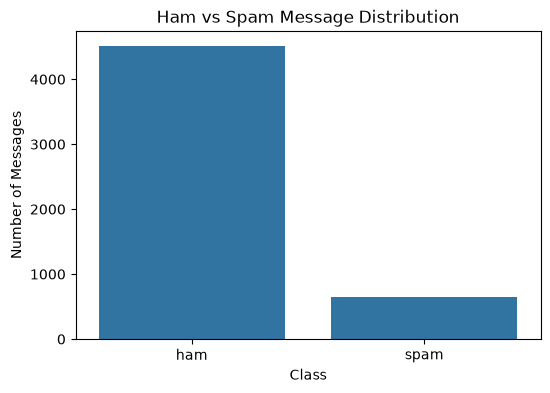

In [8]:
# Visualize the Ham/Spam class distribution.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("Ham vs Spam Message Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Messages")
plt.show()


## 7. Encode the Target Labels

The text labels are converted into numerical values:

- `ham → 0`
- `spam → 1`


In [9]:
# Convert the target labels into numerical classes.
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print(df[["label", "label_num"]].head())


  label  label_num
0   ham          0
1   ham          0
2  spam          1
3   ham          0
4   ham          0


## 8. Message Length Analysis

Message length is useful for EDA, but it is **not used as the Bernoulli NB feature**.

Bernoulli NB will use binary word-presence features.


In [10]:
# Calculate the number of characters in each SMS.
df["message_length"] = df["message"].str.len()

# Display basic statistics of message length.
print(df.groupby("label")["message_length"].describe())


        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.987600  56.736845   2.0   34.0   53.0   91.0  910.0
spam    653.0  138.130168  29.937254  13.0  132.0  149.0  157.0  224.0


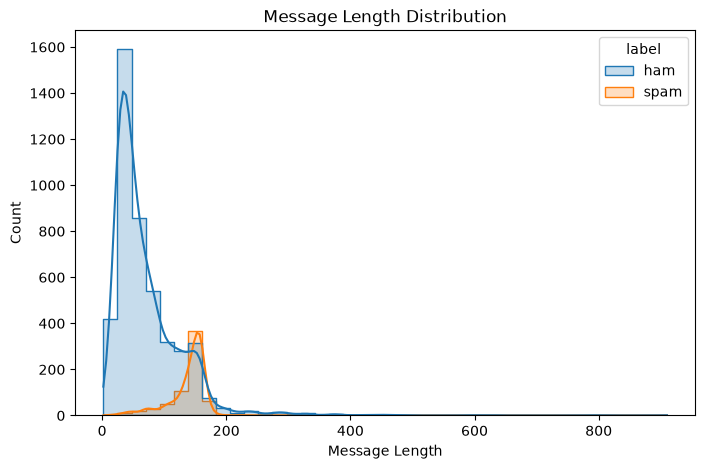

In [11]:
# Visualize message length distributions.
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=40,
    kde=True,
    element="step"
)
plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Count")
plt.show()


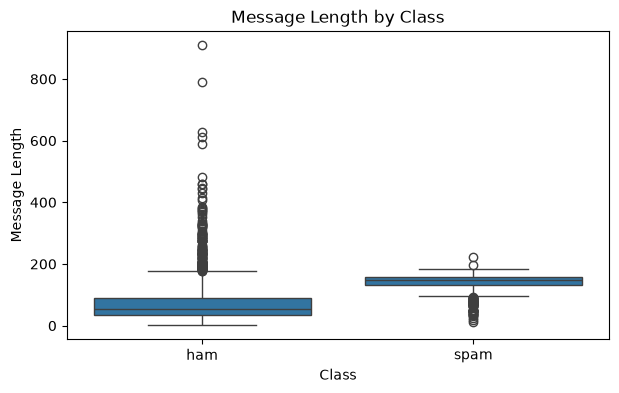

In [12]:
# Compare message length using boxplots.
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="label", y="message_length")
plt.title("Message Length by Class")
plt.xlabel("Class")
plt.ylabel("Message Length")
plt.show()


## 9. Text Preprocessing

The preprocessing used here is intentionally simple and understandable.

Steps:

1. Convert text to lowercase.
2. Keep alphabetic characters and spaces.
3. Split the message into words.

This makes words such as `FREE` and `free` equivalent.


In [13]:
# Define a simple text preprocessing function.
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    return words

# Test the preprocessing function on one message.
print(df["message"].iloc[0])
print(preprocess_text(df["message"].iloc[0]))


Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
['go', 'until', 'jurong', 'point', 'crazy', 'available', 'only', 'in', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'there', 'got', 'amore', 'wat']


## 10. Train-Test Split

The dataset is divided into training and testing data.

The vocabulary must be created from the **training data only** so that information from the test set does not influence training.

A fixed random state makes the experiment reproducible.


In [14]:
# Split the dataset into training and testing sets.
from sklearn.model_selection import train_test_split

X_text = df["message"]
y = df["label_num"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))


Training samples: 4135
Testing samples: 1034


## 11. Build the Vocabulary

The vocabulary contains unique words appearing in the training messages.

Only training messages are used to create the vocabulary.

This prevents test-set information from leaking into the model.


In [15]:
# Build a vocabulary from training messages only.
vocabulary = set()

for message in X_train_text:
    vocabulary.update(preprocess_text(message))

vocabulary = sorted(vocabulary)

print("Vocabulary size:", len(vocabulary))
print("First 20 words:", vocabulary[:20])


Vocabulary size: 6888
First 20 words: ['a', 'aa', 'aah', 'aaooooright', 'aathi', 'ab', 'abdomen', 'abeg', 'aberdeen', 'abi', 'ability', 'abiola', 'able', 'abnormally', 'about', 'aboutas', 'above', 'absolutely', 'absolutly', 'abt']


In [16]:
# Map each vocabulary word to a unique column index.
word_to_index = {
    word: index
    for index, word in enumerate(vocabulary)
}

print("Sample word-to-index mapping:")
print(list(word_to_index.items())[:20])


Sample word-to-index mapping:
[('a', 0), ('aa', 1), ('aah', 2), ('aaooooright', 3), ('aathi', 4), ('ab', 5), ('abdomen', 6), ('abeg', 7), ('aberdeen', 8), ('abi', 9), ('ability', 10), ('abiola', 11), ('able', 12), ('abnormally', 13), ('about', 14), ('aboutas', 15), ('above', 16), ('absolutely', 17), ('absolutly', 18), ('abt', 19)]


## 12. Binary Feature Representation

This is the most important difference between **Multinomial NB** and **Bernoulli NB**.

### Multinomial NB

It records **how many times** a word occurs.

Example:

```text
free free prize
free = 2
prize = 1
```

### Bernoulli NB

It only records whether the word is **present or absent**.

```text
free = 1
prize = 1
```

Even if `free` occurs five times, its Bernoulli feature remains `1`.

Therefore:

- `1` → word is present
- `0` → word is absent


In [17]:
# Convert each message into a binary word-presence vector.
def text_to_binary_vector(text):
    vector = np.zeros(len(vocabulary), dtype=np.int8)

    words = set(preprocess_text(text))

    for word in words:
        if word in word_to_index:
            vector[word_to_index[word]] = 1

    return vector


# Test the binary representation on one message.
sample_vector = text_to_binary_vector(X_train_text.iloc[0])

print("Vector shape:", sample_vector.shape)
print("Number of present words:", sample_vector.sum())


Vector shape: (6888,)
Number of present words: 10


In [18]:
# Convert all training and testing messages into binary feature matrices.
X_train = np.array([
    text_to_binary_vector(message)
    for message in X_train_text
])

X_test = np.array([
    text_to_binary_vector(message)
    for message in X_test_text
])

y_train = np.array(y_train)
y_test = np.array(y_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (4135, 6888)
X_test shape: (1034, 6888)
y_train shape: (4135,)
y_test shape: (1034,)


## 13. Class Prior Probability

The prior probability tells us how common each class is in the training data.

Formula:

\[
P(c) = \frac{N_c}{N}
\]

where:

- `N_c` = number of training messages in class `c`
- `N` = total number of training messages


In [19]:
# Calculate class prior probabilities from the training data.
classes = np.array([0, 1])

class_counts = np.array([
    np.sum(y_train == c)
    for c in classes
])

priors = class_counts / len(y_train)

print("Class counts:", class_counts)
print("Class priors:", priors)
print("P(Ham):", priors[0])
print("P(Spam):", priors[1])


Class counts: [3613  522]
Class priors: [0.87376058 0.12623942]
P(Ham): 0.8737605804111246
P(Spam): 0.12623941958887544


## 14. Count Word Presence Within Each Class

For Bernoulli NB, we count **how many documents contain each word**, not how many total times the word occurs.

For example, if `free` appears:

- in 100 Ham messages → count = 100
- in 250 Spam messages → count = 250

Repeated occurrences inside the same message still count as one presence.


In [20]:
# Count how many training documents contain each word for each class.
feature_presence_counts = np.zeros(
    (len(classes), len(vocabulary)),
    dtype=np.int64
)

for class_index, c in enumerate(classes):
    class_documents = X_train[y_train == c]

    # Sum binary vectors column-wise.
    feature_presence_counts[class_index] = class_documents.sum(axis=0)

print("Feature presence count shape:", feature_presence_counts.shape)


Feature presence count shape: (2, 6888)


## 15. Bernoulli Feature Probability with Laplace Smoothing

For Bernoulli Naive Bayes, we estimate:

\[
P(x_j = 1 | c)
\]

The probability that feature `j` is present in class `c` is:

\[
P(x_j=1|c)
=
\frac{N_{jc}+\alpha}
{N_c+2\alpha}
\]

where:

- `N_jc` = number of class-`c` documents containing feature `j`
- `N_c` = number of documents in class `c`
- `alpha` = smoothing parameter

We use:

```text
alpha = 1.0
```

The `2α` appears in the denominator because a Bernoulli feature has two possible outcomes:

- present
- absent


In [21]:
# Set the Laplace smoothing parameter.
alpha = 1.0

# Calculate P(feature = 1 | class) using Bernoulli smoothing.
feature_probs = np.zeros(
    (len(classes), len(vocabulary)),
    dtype=np.float64
)

for class_index, c in enumerate(classes):
    n_class = np.sum(y_train == c)

    feature_probs[class_index] = (
        feature_presence_counts[class_index] + alpha
    ) / (
        n_class + 2 * alpha
    )

print("Feature probability matrix shape:", feature_probs.shape)


Feature probability matrix shape: (2, 6888)


## 16. Probability of Feature Absence

Bernoulli NB uses both conditions:

- word is present
- word is absent

If:

\[
P(x_j=1|c)=p
\]

then:

\[
P(x_j=0|c)=1-p
\]

This is an important difference from Multinomial NB.


In [22]:
# Probability that each feature is absent given each class.
feature_absent_probs = 1 - feature_probs

print("Example present probabilities:", feature_probs[:, :5])
print("Example absent probabilities:", feature_absent_probs[:, :5])


Example present probabilities: [[0.17842324 0.00055325 0.0011065  0.00055325 0.00055325]
 [0.38549618 0.0019084  0.0019084  0.0019084  0.0019084 ]]
Example absent probabilities: [[0.82157676 0.99944675 0.9988935  0.99944675 0.99944675]
 [0.61450382 0.9980916  0.9980916  0.9980916  0.9980916 ]]


## 17. Bernoulli Naive Bayes Mathematical Working

For a binary feature vector `X`:

\[
P(X|c)
=
\prod_j
P(x_j=1|c)^{x_j}
P(x_j=0|c)^{1-x_j}
\]

Using Bayes' theorem:

\[
P(c|X) \propto P(c)P(X|c)
\]

Therefore:

\[
Score(c)
=
P(c)
\prod_j
P(x_j=1|c)^{x_j}
P(x_j=0|c)^{1-x_j}
\]

We use logarithms for numerical stability:

\[
logScore(c)
=
logP(c)
+
\sum_j
[
x_j logP(x_j=1|c)
+
(1-x_j)logP(x_j=0|c)
]
\]

The class with the largest log score is selected.


## 18. From-Scratch Bernoulli Naive Bayes

The following class implements the important mathematical steps directly.

No ready-made Bernoulli Naive Bayes classifier is used here.


In [23]:
# ---------------------------------------------------------
# FROM-SCRATCH BERNOULLI NAIVE BAYES
# ---------------------------------------------------------

class BernoulliNBFromScratch:

    def __init__(self, alpha=1.0):
        # Store the Laplace smoothing parameter.
        self.alpha = alpha

    def fit(self, X, y):
        # Store the unique class labels.
        self.classes_ = np.unique(y)

        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        # Store class priors.
        self.class_prior_ = np.zeros(n_classes)

        # Store P(feature=1 | class).
        self.feature_prob_ = np.zeros(
            (n_classes, n_features)
        )

        for class_index, c in enumerate(self.classes_):

            # Select documents belonging to the current class.
            X_class = X[y == c]

            n_class = X_class.shape[0]

            # Calculate class prior.
            self.class_prior_[class_index] = (
                n_class / n_samples
            )

            # Count documents where each word is present.
            feature_count = X_class.sum(axis=0)

            # Bernoulli Laplace smoothing.
            self.feature_prob_[class_index] = (
                feature_count + self.alpha
            ) / (
                n_class + 2 * self.alpha
            )

        return self

    def predict(self, X):

        predictions = []

        # Calculate predictions one document at a time.
        for sample in X:

            scores = []

            for class_index, c in enumerate(self.classes_):

                # Probability that feature is present.
                p_present = self.feature_prob_[class_index]

                # Probability that feature is absent.
                p_absent = 1 - p_present

                # Calculate log probability.
                log_score = np.log(
                    self.class_prior_[class_index]
                )

                log_score += np.sum(
                    sample * np.log(p_present)
                    + (1 - sample) * np.log(p_absent)
                )

                scores.append(log_score)

            # Select the class with the highest score.
            predictions.append(
                self.classes_[np.argmax(scores)]
            )

        return np.array(predictions)


## 19. Train the From-Scratch Model


In [24]:
# Create and train the from-scratch Bernoulli NB model.
scratch_model = BernoulliNBFromScratch(alpha=1.0)

scratch_model.fit(X_train, y_train)

print("Model trained successfully!")
print("Classes:", scratch_model.classes_)


Model trained successfully!
Classes: [0 1]


## 20. Generate Predictions

The trained model calculates a log score for Ham and Spam for each test message.

The class with the larger score becomes the prediction.


In [25]:
# Generate predictions for the test set.
y_pred_scratch = scratch_model.predict(X_test)

print("First 20 predictions:")
print(y_pred_scratch[:20])


First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 21. Evaluate the From-Scratch Model

We calculate the main classification metrics manually so that the evaluation logic is also understandable.

For this project, Spam (`1`) is the positive class.


In [26]:
# Calculate confusion-matrix values manually.
TP = np.sum((y_test == 1) & (y_pred_scratch == 1))
TN = np.sum((y_test == 0) & (y_pred_scratch == 0))
FP = np.sum((y_test == 0) & (y_pred_scratch == 1))
FN = np.sum((y_test == 1) & (y_pred_scratch == 0))

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)


TP: 111
TN: 902
FP: 1
FN: 20


In [27]:
# Calculate Accuracy, Precision, Recall and F1 Score.
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) != 0 else 0

recall = TP / (TP + FN) if (TP + FN) != 0 else 0

f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) != 0
    else 0
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.9796905222437138
Precision: 0.9910714285714286
Recall: 0.8473282442748091
F1 Score: 0.9135802469135802


## 22. Confusion Matrix Visualization

The confusion matrix helps us understand which predictions are correct and which types of errors the model makes.


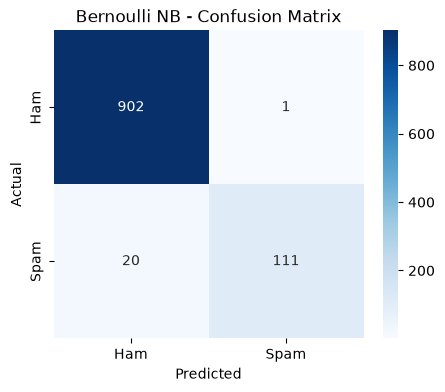

In [28]:
# Create and visualize the confusion matrix.
confusion_matrix = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Bernoulli NB - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 23. Scikit-learn Bernoulli Naive Bayes

Now we implement the same algorithm using Scikit-learn.

Important: this is kept separate from the from-scratch implementation. The scratch model above does not call Scikit-learn's BernoulliNB internally.


In [29]:
# Import Scikit-learn's Bernoulli Naive Bayes implementation.
from sklearn.naive_bayes import BernoulliNB

# Create the library model with the same alpha value.
sk_model = BernoulliNB(alpha=1.0)

# Train the Scikit-learn model using the same binary features.
sk_model.fit(X_train, y_train)

print("Scikit-learn model trained successfully!")


Scikit-learn model trained successfully!


## 24. Scikit-learn Predictions and Evaluation


In [30]:
# Generate predictions using Scikit-learn.
y_pred_sk = sk_model.predict(X_test)

print("First 20 predictions:")
print(y_pred_sk[:20])


First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [31]:
# Calculate Scikit-learn metrics manually using its predictions.
TP_sk = np.sum((y_test == 1) & (y_pred_sk == 1))
TN_sk = np.sum((y_test == 0) & (y_pred_sk == 0))
FP_sk = np.sum((y_test == 0) & (y_pred_sk == 1))
FN_sk = np.sum((y_test == 1) & (y_pred_sk == 0))

accuracy_sk = (TP_sk + TN_sk) / (TP_sk + TN_sk + FP_sk + FN_sk)

precision_sk = (
    TP_sk / (TP_sk + FP_sk)
    if (TP_sk + FP_sk) != 0 else 0
)

recall_sk = (
    TP_sk / (TP_sk + FN_sk)
    if (TP_sk + FN_sk) != 0 else 0
)

f1_sk = (
    2 * precision_sk * recall_sk / (precision_sk + recall_sk)
    if (precision_sk + recall_sk) != 0 else 0
)

print("Accuracy:", accuracy_sk)
print("Precision:", precision_sk)
print("Recall:", recall_sk)
print("F1 Score:", f1_sk)


Accuracy: 0.9796905222437138
Precision: 0.9910714285714286
Recall: 0.8473282442748091
F1 Score: 0.9135802469135802


## 25. From-Scratch vs Scikit-learn Comparison

The two implementations are evaluated on exactly the same test data.

We compare:

- Accuracy
- Precision
- Recall
- F1 Score
- Prediction agreement


In [32]:
# Create a comparison table for both implementations.
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "From Scratch": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Scikit-learn": [
        accuracy_sk,
        precision_sk,
        recall_sk,
        f1_sk
    ]
})

comparison


,Metric,From Scratch,Scikit-learn
0,Accuracy,0.979691,0.979691
1,Precision,0.991071,0.991071
2,Recall,0.847328,0.847328
3,F1 Score,0.913580,0.913580


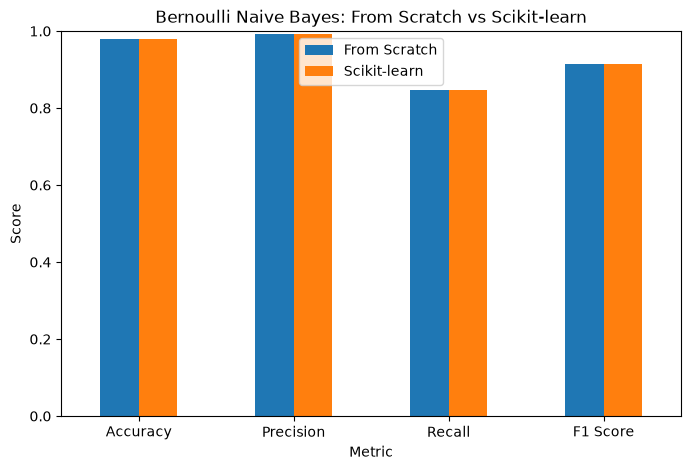

In [33]:
# Visualize the metric comparison.
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Bernoulli Naive Bayes: From Scratch vs Scikit-learn")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()


## 26. Prediction Agreement

Prediction agreement measures how often the two implementations make exactly the same prediction.


In [34]:
# Calculate prediction agreement.
agreement = np.mean(
    y_pred_scratch == y_pred_sk
)

agreement_percentage = agreement * 100

print("Prediction Agreement:", agreement)
print("Prediction Agreement (%):", agreement_percentage)


Prediction Agreement: 1.0
Prediction Agreement (%): 100.0


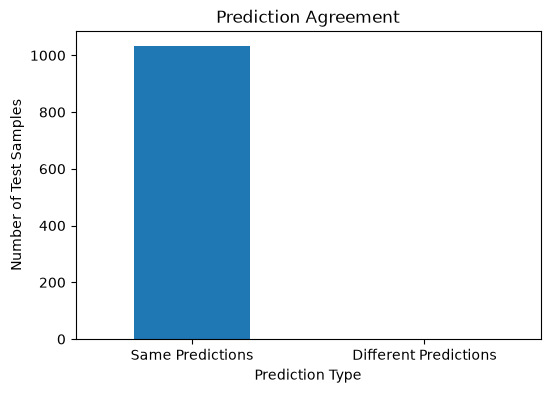

In [35]:
# Visualize the number of same and different predictions.
same_predictions = np.sum(y_pred_scratch == y_pred_sk)
different_predictions = np.sum(y_pred_scratch != y_pred_sk)

agreement_data = pd.Series({
    "Same Predictions": same_predictions,
    "Different Predictions": different_predictions
})

agreement_data.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Prediction Agreement")
plt.xlabel("Prediction Type")
plt.ylabel("Number of Test Samples")
plt.xticks(rotation=0)
plt.show()


## 27. Top Words by Presence Probability

For Bernoulli NB, we can inspect words with high:

\[
P(word\ present | class)
\]

This helps us understand which words are commonly present in each class.

This is a model-behavior visualization, not merely a decorative plot.


In [36]:
# Find words with the highest presence probability for each class.
ham_top_indices = np.argsort(
    scratch_model.feature_prob_[0]
)[-15:]

spam_top_indices = np.argsort(
    scratch_model.feature_prob_[1]
)[-15:]

ham_top_words = [
    vocabulary[i]
    for i in ham_top_indices
]

spam_top_words = [
    vocabulary[i]
    for i in spam_top_indices
]

print("Top Ham words:")
print(ham_top_words)

print("\nTop Spam words:")
print(spam_top_words)


Top Ham words:
['of', 'for', 'that', 'is', 'my', 'it', 'me', 'u', 'and', 'in', 'a', 'the', 'to', 'you', 'i']

Top Spam words:
['from', 'u', 'txt', 'is', 'p', 'free', 'the', 'or', 'now', 'for', 'your', 'you', 'a', 'call', 'to']


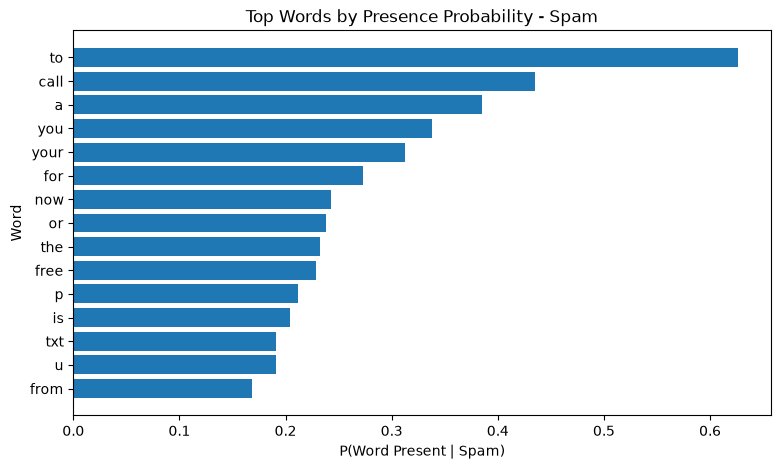

In [37]:
# Visualize the top Spam words by P(word present | Spam).
spam_values = scratch_model.feature_prob_[1][spam_top_indices]

plt.figure(figsize=(9, 5))
plt.barh(spam_top_words, spam_values)
plt.title("Top Words by Presence Probability - Spam")
plt.xlabel("P(Word Present | Spam)")
plt.ylabel("Word")
plt.show()


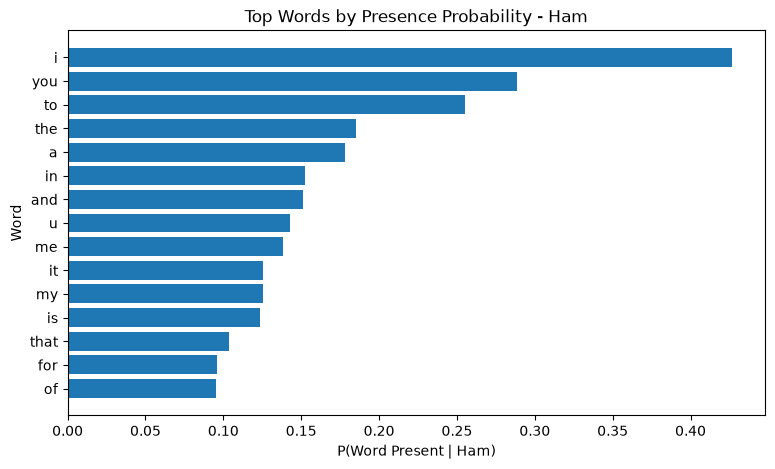

In [38]:
# Visualize the top Ham words by P(word present | Ham).
ham_values = scratch_model.feature_prob_[0][ham_top_indices]

plt.figure(figsize=(9, 5))
plt.barh(ham_top_words, ham_values)
plt.title("Top Words by Presence Probability - Ham")
plt.xlabel("P(Word Present | Ham)")
plt.ylabel("Word")
plt.show()


## 28. Hyperparameter: alpha

The main smoothing hyperparameter is `alpha`.

For Bernoulli Naive Bayes:

\[
P(x_j=1|c)
=
\frac{count(x_j=1,c)+\alpha}
{N_c+2\alpha}
\]

In this project:

```text
alpha = 1.0
```

This is Laplace smoothing.

- Larger `alpha` → stronger smoothing
- Smaller positive `alpha` → weaker smoothing

Smoothing prevents probabilities from becoming exactly zero or one for features that are absent or present in all training documents of a class.


## 29. Computational Complexity

Let:

- `N` = number of training documents
- `V` = vocabulary size
- `C` = number of classes
- `T` = number of test documents

### Training

Creating the binary document-term matrix depends on the number of words in the training data.

The class-wise probability table has `C × V` values.

Approximate training cost for the dense representation:

**O(N × V)**

### Prediction

For one document, the model evaluates all vocabulary features for every class:

**O(C × V)**

For `T` test documents:

**O(T × C × V)**

### Space

The learned probability table requires:

**O(C × V)**

The binary training matrix itself can require approximately:

**O(N × V)**

when stored densely.


## 30. Applications

Bernoulli Naive Bayes is useful when features represent binary presence/absence information.

Common applications include:

- SMS spam detection
- Email spam filtering
- Binary text classification
- Document classification
- Topic classification using word presence
- Presence/absence based classification problems


## 31. Advantages and Limitations

### Advantages

- Simple and easy to understand.
- Fast training and prediction.
- Works naturally with binary features.
- Useful for high-dimensional text data.
- Easy to implement from scratch.

### Limitations

- The conditional independence assumption may not hold in real text.
- Word order and deeper semantic relationships are ignored.
- Performance depends on preprocessing and vocabulary.
- Binary representation ignores how many times a word occurs.


## 32. Conclusion

Bernoulli Naive Bayes was implemented from scratch using Python and NumPy for SMS Spam Classification.

The model represents each SMS using **binary word-presence features**, where:

- `1` means the word is present.
- `0` means the word is absent.

The implementation manually calculates:

- Class priors
- Class-wise feature presence counts
- Bernoulli feature probabilities
- Laplace smoothing
- Probability of feature absence
- Log-probability scores
- Final predictions

The from-scratch implementation is compared with Scikit-learn's `BernoulliNB` using the same binary features and test data.

This project demonstrates how Bernoulli Naive Bayes differs from Multinomial Naive Bayes: **Bernoulli NB focuses on whether a feature is present or absent, while Multinomial NB uses feature counts.**


# Final Project Checklist

Before considering this notebook complete, verify:

- [ ] Dataset loaded correctly
- [ ] Missing values checked
- [ ] Duplicates handled
- [ ] EDA completed
- [ ] Class distribution visualized
- [ ] Message-length analysis completed
- [ ] Text preprocessing explained
- [ ] Train-test split performed
- [ ] Vocabulary created from training data only
- [ ] Binary feature representation implemented from scratch
- [ ] Class priors calculated
- [ ] Bernoulli probabilities calculated
- [ ] Laplace smoothing implemented
- [ ] Log-probability prediction implemented
- [ ] Evaluation metrics calculated
- [ ] Confusion matrix visualized
- [ ] Scikit-learn BernoulliNB implemented
- [ ] Scratch vs Scikit-learn comparison completed
- [ ] Prediction agreement calculated
- [ ] Algorithm behavior visualized
- [ ] Hyperparameter explained
- [ ] Complexity explained
- [ ] Applications documented
- [ ] Advantages and limitations documented
- [ ] Conclusion added
